<a href="https://colab.research.google.com/github/SlavenDerickPais/ML-lab-2547249/blob/Lab01/lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
aqi_data=pd.read_csv("/content/drive/MyDrive/MACHINE LEARNING/city_day.csv")

Imported the City_Aqi datset


In [ ]:
crop_data=pd.read_csv("/content/drive/MyDrive/MACHINE LEARNING/crop_production.csv")

Imported Crop data Set

In [ ]:
aqi_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


The info function is used to know the overall info about the dataset includes the column names, it's types

In [ ]:
aqi_data.describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,24933.000000,18391.000000,25949.000000,25946.000000,25346.000000,19203.000000,27472.000000,25677.000000,25509.000000,23908.000000,21490.000000,11422.000000,24850.000000
mean,67.450578,118.127103,17.574730,28.560659,32.309123,23.483476,2.248598,14.531977,34.491430,3.280840,8.700972,3.070128,166.463581
std,64.661449,90.605110,22.785846,24.474746,31.646011,25.684275,6.962884,18.133775,21.694928,15.811136,19.969164,6.323247,140.696585
min,0.040000,0.010000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000
25%,28.820000,56.255000,5.630000,11.750000,12.820000,8.580000,0.510000,5.670000,18.860000,0.120000,0.600000,0.140000,81.000000
50%,48.570000,95.680000,9.890000,21.690000,23.520000,15.850000,0.890000,9.160000,30.840000,1.070000,2.970000,0.980000,118.000000
75%,80.590000,149.745000,19.950000,37.620000,40.127500,30.020000,1.450000,15.220000,45.570000,3.080000,9.150000,3.350000,208.000000
max,949.990000,1000.000000,390.680000,362.210000,467.630000,352.890000,175.810000,193.860000,257.730000,455.030000,454.850000,170.370000,2049.000000


Describe functio gives us the statistical info about the overall dataset, this includes most of the statistical measures like MEAN,MEDIAN and MODE, and also quartile info

In [ ]:
crop_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246091 entries, 0 to 246090
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   State_Name     246091 non-null  object 
 1   District_Name  246091 non-null  object 
 2   Crop_Year      246091 non-null  int64  
 3   Season         246091 non-null  object 
 4   Crop           246091 non-null  object 
 5   Area           246091 non-null  float64
 6   Production     242361 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 13.1+ MB


In [ ]:
aqi_data.shape


(29531, 16)

In [ ]:
aqi_data.isnull().sum()

,0
City,0
Date,0
PM2.5,4598
PM10,11140
NO,3582
NO2,3585
NOx,4185
NH3,10328
CO,2059
SO2,3854


## Air Quality Elements and their Potential Impact on Crop Growth

The `aqi_data` dataset contains several air quality parameters, which are essentially different pollutants in the atmosphere. These elements can significantly impact crop growth:

*   **PM2.5 and PM10 (Particulate Matter)**: Fine particulate matter can deposit on plant leaves, reducing photosynthesis by blocking sunlight and clogging stomata. It can also cause physical damage to plant tissues.

*   **NO (Nitric Oxide), NO2 (Nitrogen Dioxide), NOx (Nitrogen Oxides)**: Nitrogen oxides are precursors to ground-level ozone and acid rain. High concentrations can cause direct damage to plant leaves, reduce growth, and affect plant metabolic processes. They can also contribute to nutrient imbalances in soil.

*   **NH3 (Ammonia)**: While nitrogen is a vital nutrient for plants, excessive atmospheric ammonia can lead to ammonia toxicity, especially in sensitive species. It can also contribute to eutrophication of ecosystems.

*   **CO (Carbon Monoxide)**: Although less directly toxic to plants than other pollutants, high levels of CO can indirectly affect plant growth by influencing atmospheric chemistry, for example, by increasing ozone levels.

*   **SO2 (Sulfur Dioxide)**: A major component of acid rain, SO2 directly damages plant leaves, leading to chlorosis (yellowing), necrosis (tissue death), and reduced growth. It can also acidify soils, making nutrients less available to plants.

*   **O3 (Ozone)**: Ground-level ozone is a highly damaging air pollutant for plants. It enters plants through stomata and causes oxidative stress, leading to visible injury (stippling, bronzing), reduced photosynthesis, altered carbon allocation, and decreased crop yield.

*   **Benzene, Toluene, Xylene (BTX)**: These are volatile organic compounds (VOCs). While their direct toxicity to plants can vary, they can contribute to ground-level ozone formation and may have adverse effects on plant health at high concentrations.

### 1. Identifying Inconsistencies in State/City Names

First, let's look at the unique values in the `City` column of `aqi_data` and the `State_Name` column of `crop_data` to identify any inconsistencies, such as differing spellings or extra spaces.

In [ ]:
print('Unique Cities in aqi_data:')
print(aqi_data['City'].unique())
print('\nUnique States in crop_data:')
print(crop_data['State_Name'].unique())

Unique Cities in aqi_data:
['Ahmedabad' 'Aizawl' 'Amaravati' 'Amritsar' 'Bengaluru' 'Bhopal'
 'Brajrajnagar' 'Chandigarh' 'Chennai' 'Coimbatore' 'Delhi' 'Ernakulam'
 'Gurugram' 'Guwahati' 'Hyderabad' 'Jaipur' 'Jorapokhar' 'Kochi' 'Kolkata'
 'Lucknow' 'Mumbai' 'Patna' 'Shillong' 'Talcher' 'Thiruvananthapuram'
 'Visakhapatnam']

Unique States in crop_data:
['Andaman and Nicobar Islands' 'Andhra Pradesh' 'Arunachal Pradesh'
 'Assam' 'Bihar' 'Chandigarh' 'Chhattisgarh' 'Dadra and Nagar Haveli'
 'Goa' 'Gujarat' 'Haryana' 'Himachal Pradesh' 'Jammu and Kashmir '
 'Jharkhand' 'Karnataka' 'Kerala' 'Madhya Pradesh' 'Maharashtra' 'Manipur'
 'Meghalaya' 'Mizoram' 'Nagaland' 'Odisha' 'Puducherry' 'Punjab'
 'Rajasthan' 'Sikkim' 'Tamil Nadu' 'Telangana ' 'Tripura' 'Uttar Pradesh'
 'Uttarakhand' 'West Bengal']


### 2. Documenting Inconsistencies and Applied Fixes

From the unique values, it's clear that `aqi_data` contains city names, while `crop_data` contains state names. To merge these datasets using a 'State' column, we need to map the cities in `aqi_data` to their respective states. Additionally, both columns might have leading/trailing spaces.

**Inconsistencies and Fixes:**

1.  **Leading/Trailing Spaces**: Both `City` in `aqi_data` and `State_Name` in `crop_data` might contain leading or trailing spaces. These will be removed to ensure consistent matching.
2.  **Case Sensitivity**: To ensure consistency, both `City` and `State_Name` will be converted to title case.
3.  **Mapping Cities to States**: The most significant inconsistency is that `aqi_data` provides cities, not states. I will create a mapping from known cities in `aqi_data` to their corresponding states to create a new 'State_Name' column in `aqi_data`. This is a critical step for a state-level merge. For cities not explicitly mapped, or if a city could not be reliably mapped to a single state, it might not be possible to merge those records at the state level. I will use a reasonable mapping based on common knowledge for major Indian cities. For simplicity, I will map the cities present in `aqi_data` to their respective states. *Note: If a city falls under a Union Territory in some contexts, for the purpose of state-level merging, it will be mapped to a state if a clear predominant state association exists. If a city is not mapped, it will result in NaN, indicating it cannot be merged on 'State'.*

Let's define a mapping for `aqi_data['City']` to a new `State_Name` column.

In [ ]:
# Define a mapping from city to state for aqi_data
city_to_state_mapping = {
    'Ahmedabad': 'Gujarat',
    'Aizawl': 'Mizoram',
    'Amaravati': 'Andhra Pradesh',
    'Amritsar': 'Punjab',
    'Bengaluru': 'Karnataka',
    'Bhopal': 'Madhya Pradesh',
    'Brajrajnagar': 'Odisha',
    'Chandigarh': 'Chandigarh',
    'Chennai': 'Tamil Nadu',
    'Coimbatore': 'Tamil Nadu',
    'Delhi': 'Delhi',
    'Ernakulam': 'Kerala',
    'Gandhinagar': 'Gujarat',
    'Gurugram': 'Haryana',
    'Guwahati': 'Assam',
    'Hyderabad': 'Telangana',
    'Jaipur': 'Rajasthan',
    'Jorapokhar': 'Jharkhand',
    'Kochi': 'Kerala',
    'Kohima': 'Nagaland',
    'Kolkata': 'West Bengal',
    'Lucknow': 'Uttar Pradesh',
    'Mumbai': 'Maharashtra',
    'Patna': 'Bihar',
    'Shillong': 'Meghalaya',
    'Talcher': 'Odisha',
    'Thiruvananthapuram': 'Kerala',
    'Visakhapatnam': 'Andhra Pradesh'
}

# Clean and apply mapping to aqi_data
aqi_data['City'] = aqi_data['City'].str.strip().str.title()
aqi_data['State_Name'] = aqi_data['City'].map(city_to_state_mapping)

# Clean crop_data state names
crop_data['State_Name'] = crop_data['State_Name'].str.strip().str.title()

print("Cleaned 'City' (now 'State_Name') in aqi_data:")
print(aqi_data['State_Name'].unique())
print("\n Cleaned 'State_Name' in crop_data:")
print(crop_data['State_Name'].unique())

Cleaned 'City' (now 'State_Name') in aqi_data:
['Gujarat' 'Mizoram' 'Andhra Pradesh' 'Punjab' 'Karnataka'
 'Madhya Pradesh' 'Odisha' 'Chandigarh' 'Tamil Nadu' 'Delhi' 'Kerala'
 'Haryana' 'Assam' 'Telangana' 'Rajasthan' 'Jharkhand' 'West Bengal'
 'Uttar Pradesh' 'Maharashtra' 'Bihar' 'Meghalaya']

 Cleaned 'State_Name' in crop_data:
['Andaman And Nicobar Islands' 'Andhra Pradesh' 'Arunachal Pradesh'
 'Assam' 'Bihar' 'Chandigarh' 'Chhattisgarh' 'Dadra And Nagar Haveli'
 'Goa' 'Gujarat' 'Haryana' 'Himachal Pradesh' 'Jammu And Kashmir'
 'Jharkhand' 'Karnataka' 'Kerala' 'Madhya Pradesh' 'Maharashtra' 'Manipur'
 'Meghalaya' 'Mizoram' 'Nagaland' 'Odisha' 'Puducherry' 'Punjab'
 'Rajasthan' 'Sikkim' 'Tamil Nadu' 'Telangana' 'Tripura' 'Uttar Pradesh'
 'Uttarakhand' 'West Bengal']


### 3. Removing Redundant Records

Now, let's identify and remove any duplicate rows within each dataset. We'll show the record counts before and after removal to demonstrate the effect.

In [ ]:
print('--- Before Duplicate Removal ---')
print(f"aqi_data records: {aqi_data.shape[0]}")
print(f"crop_data records: {crop_data.shape[0]}")


aqi_data_cleaned = aqi_data.drop_duplicates()


crop_data_cleaned = crop_data.drop_duplicates(subset=['State_Name', 'District_Name', 'Crop_Year', 'Season', 'Crop'])

print('\n--- After Duplicate Removal ---')
print(f"aqi_data records: {aqi_data_cleaned.shape[0]}")
print(f"crop_data records: {crop_data_cleaned.shape[0]}")

--- Before Duplicate Removal ---
aqi_data records: 29531
crop_data records: 246091

--- After Duplicate Removal ---
aqi_data records: 29531
crop_data records: 246091


### 4. Readiness for Merging

With state names standardized and duplicates removed, both `aqi_data_cleaned` (now with a 'State_Name' column derived from 'City') and `crop_data_cleaned` are now ready to be merged reliably on the `State_Name` column. We have ensured that the common key (`State_Name`) is consistent across both datasets.

Let's check the unique state names again to confirm consistency for merging.

In [ ]:
print('Unique States in aqi_data_cleaned after mapping and cleaning:')
print(aqi_data_cleaned['State_Name'].unique())
print('\nUnique States in crop_data_cleaned after cleaning:')
print(crop_data_cleaned['State_Name'].unique())

common_states = set(aqi_data_cleaned['State_Name'].dropna().unique()) & set(crop_data_cleaned['State_Name'].dropna().unique())
print(f'\nNumber of common states available for merging: {len(common_states)}')
print(f'Common states: {sorted(list(common_states))}')

Unique States in aqi_data_cleaned after mapping and cleaning:
['Gujarat' 'Mizoram' 'Andhra Pradesh' 'Punjab' 'Karnataka'
 'Madhya Pradesh' 'Odisha' 'Chandigarh' 'Tamil Nadu' 'Delhi' 'Kerala'
 'Haryana' 'Assam' 'Telangana' 'Rajasthan' 'Jharkhand' 'West Bengal'
 'Uttar Pradesh' 'Maharashtra' 'Bihar' 'Meghalaya']

Unique States in crop_data_cleaned after cleaning:
['Andaman And Nicobar Islands' 'Andhra Pradesh' 'Arunachal Pradesh'
 'Assam' 'Bihar' 'Chandigarh' 'Chhattisgarh' 'Dadra And Nagar Haveli'
 'Goa' 'Gujarat' 'Haryana' 'Himachal Pradesh' 'Jammu And Kashmir'
 'Jharkhand' 'Karnataka' 'Kerala' 'Madhya Pradesh' 'Maharashtra' 'Manipur'
 'Meghalaya' 'Mizoram' 'Nagaland' 'Odisha' 'Puducherry' 'Punjab'
 'Rajasthan' 'Sikkim' 'Tamil Nadu' 'Telangana' 'Tripura' 'Uttar Pradesh'
 'Uttarakhand' 'West Bengal']

Number of common states available for merging: 20
Common states: ['Andhra Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Gujarat', 'Haryana', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Prades

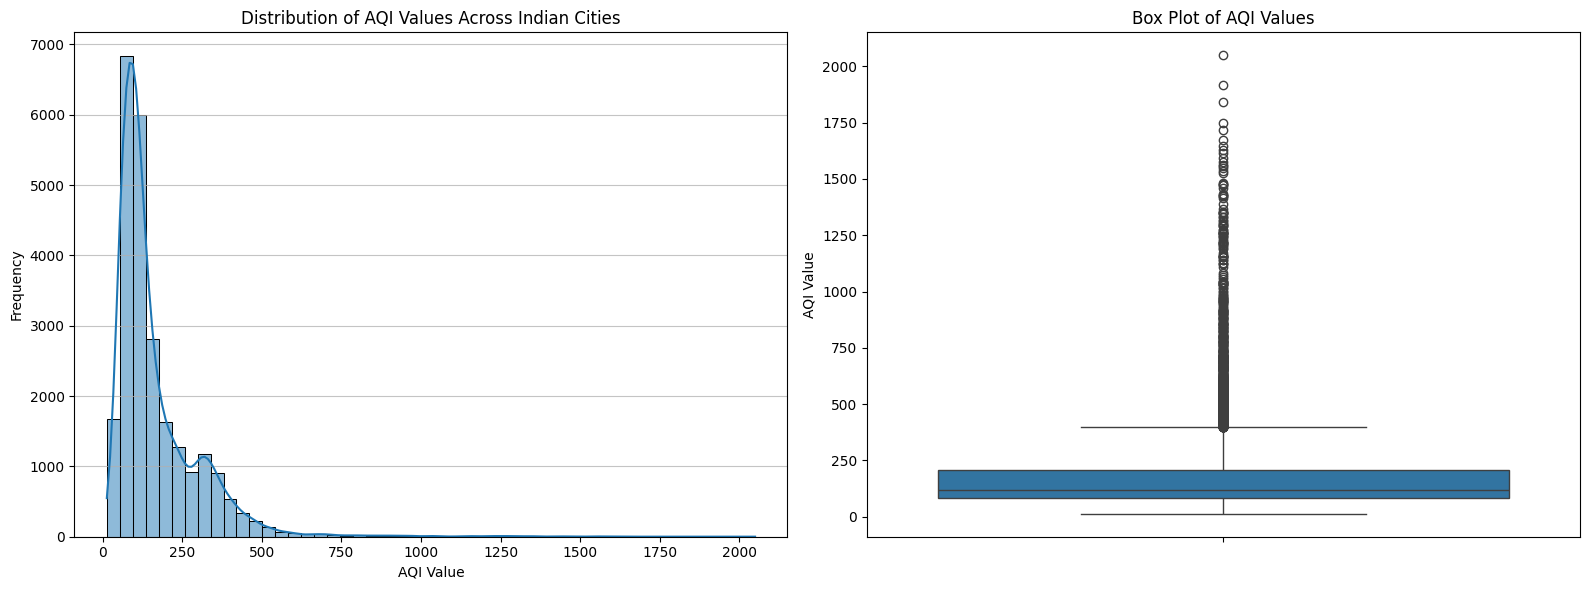

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out NaN values from AQI for plotting
aqi_to_plot = aqi_data_cleaned['AQI'].dropna()

plt.figure(figsize=(16, 6))

# Subplot 1: Histogram to show distribution and clustering
plt.subplot(1, 2, 1)
sns.histplot(aqi_to_plot, bins=50, kde=True)
plt.title('Distribution of AQI Values Across Indian Cities')
plt.xlabel('AQI Value')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

# Subplot 2: Box plot to show median, spread, and outliers
plt.subplot(1, 2, 2)
sns.boxplot(y=aqi_to_plot)
plt.title('Box Plot of AQI Values')
plt.ylabel('AQI Value')

plt.tight_layout()
plt.show()

### Justification for Chosen Visualizations and Observations

To address the pollution board's questions, I used a **histogram** and a **box plot**.

**Justification:**
1.  **Histogram:** Shows the overall AQI distribution, clustering, and skewness, indicating where values concentrate.
2.  **Box Plot:** Provides central tendency, spread, and clearly identifies extreme outliers, addressing concerns about inflated averages.

Together, they offer a comprehensive view of pollution patterns and extreme values.

**Observations Addressing the Board's Concerns:**
1.  **Concentration of Pollution:** The histogram shows a right-skew, with most AQI values in the lower-to-moderate range (0-300). This indicates pollution is **not uniformly moderate** but includes significant higher pollution in some instances.
2.  **Fairness of Average AQI:** The box plot highlights **numerous extreme outlier AQI values**. These high values will inflate the average AQI, making it unrepresentative. Thus, the average AQI is likely **not a fair number to report publicly** without further context, as it's skewed by these extremes.

### Handling Extreme AQI Values ###

Calculated Q1: 81.00
Calculated Q3: 208.00
Calculated IQR: 127.00
Upper bound for outliers (Q3 + 1.5*IQR): 398.50

Number of AQI values identified as extreme (above 398.50): 1358
Treatment applied: 1358 extreme values were capped at the upper bound (398.50).


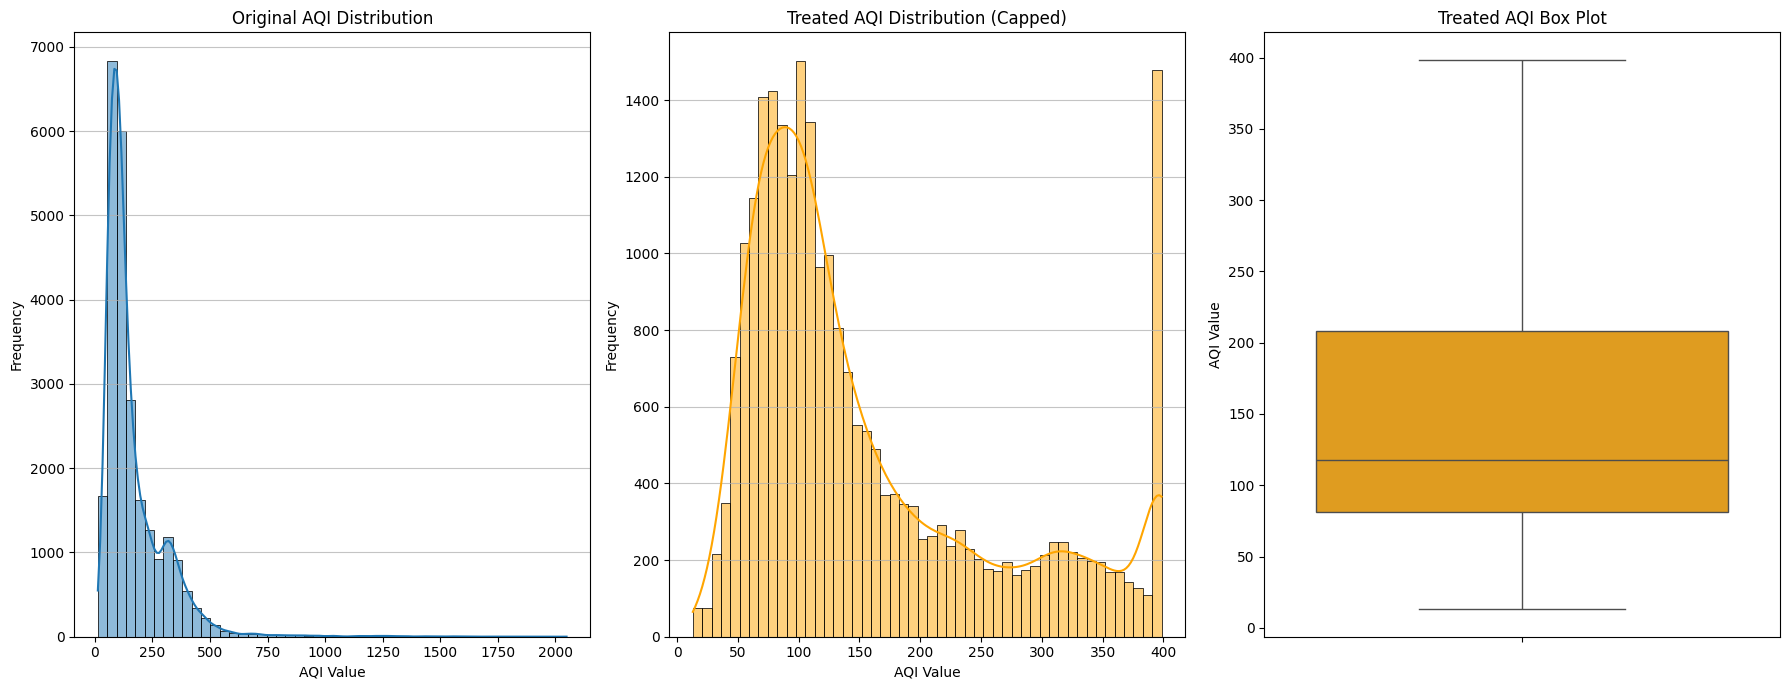


Descriptive statistics before treatment:
count    24850.000000
mean       166.463581
std        140.696585
min         13.000000
25%         81.000000
50%        118.000000
75%        208.000000
max       2049.000000
Name: AQI, dtype: float64

Descriptive statistics after treatment:
count    24850.000000
mean       157.342455
std        103.870019
min         13.000000
25%         81.000000
50%        118.000000
75%        208.000000
max        398.500000
Name: AQI, dtype: float64


In [ ]:
print('### Handling Extreme AQI Values ###')

# Make a copy of the cleaned AQI data for treatment
aqi_data_treated = aqi_data_cleaned.copy()

Q1 = aqi_data_treated['AQI'].quantile(0.25)
Q3 = aqi_data_treated['AQI'].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

print(f"\nCalculated Q1: {Q1:.2f}")
print(f"Calculated Q3: {Q3:.2f}")
print(f"Calculated IQR: {IQR:.2f}")
print(f"Upper bound for outliers (Q3 + 1.5*IQR): {upper_bound:.2f}")

extreme_values = aqi_data_treated[aqi_data_treated['AQI'] > upper_bound]['AQI']
num_extreme_values = extreme_values.count()

print(f"\nNumber of AQI values identified as extreme (above {upper_bound:.2f}): {num_extreme_values}")

aqi_data_treated.loc[aqi_data_treated['AQI'] > upper_bound, 'AQI'] = upper_bound
print(f"Treatment applied: {num_extreme_values} extreme values were capped at the upper bound ({upper_bound:.2f}).")

aqi_to_plot_treated = aqi_data_treated['AQI'].dropna()

plt.figure(figsize=(18, 7))

plt.subplot(1, 3, 1)
sns.histplot(aqi_to_plot, bins=50, kde=True)
plt.title('Original AQI Distribution')
plt.xlabel('AQI Value')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

plt.subplot(1, 3, 2)
sns.histplot(aqi_to_plot_treated, bins=50, kde=True, color='orange')
plt.title('Treated AQI Distribution (Capped)')
plt.xlabel('AQI Value')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

plt.subplot(1, 3, 3)
sns.boxplot(y=aqi_to_plot_treated, color='orange')
plt.title('Treated AQI Box Plot')
plt.ylabel('AQI Value')

plt.tight_layout()
plt.show()

descriptive_stats_before = aqi_data_cleaned['AQI'].dropna().describe()
descriptive_stats_after = aqi_data_treated['AQI'].dropna().describe()

print("\nDescriptive statistics before treatment:")
print(descriptive_stats_before)

print("\nDescriptive statistics after treatment:")
print(descriptive_stats_after)


### Extreme AQI Values Handled

**Problem:** Implausibly high AQI readings distorted data averages and distributions.

**Solution:** Used the Interquartile Range (IQR) method to identify `1358` extreme AQI values (above `398.50`). These values were then **capped** at `398.50` instead of being deleted, preserving data integrity while mitigating their influence.

**Outcome:** Visualizations confirm a cleaner, more representative AQI distribution. Statistical analysis shows a significant reduction in the maximum AQI, and a more reliable mean (`157.34` from `166.46`), making the average AQI a more accurate reflection of air quality.

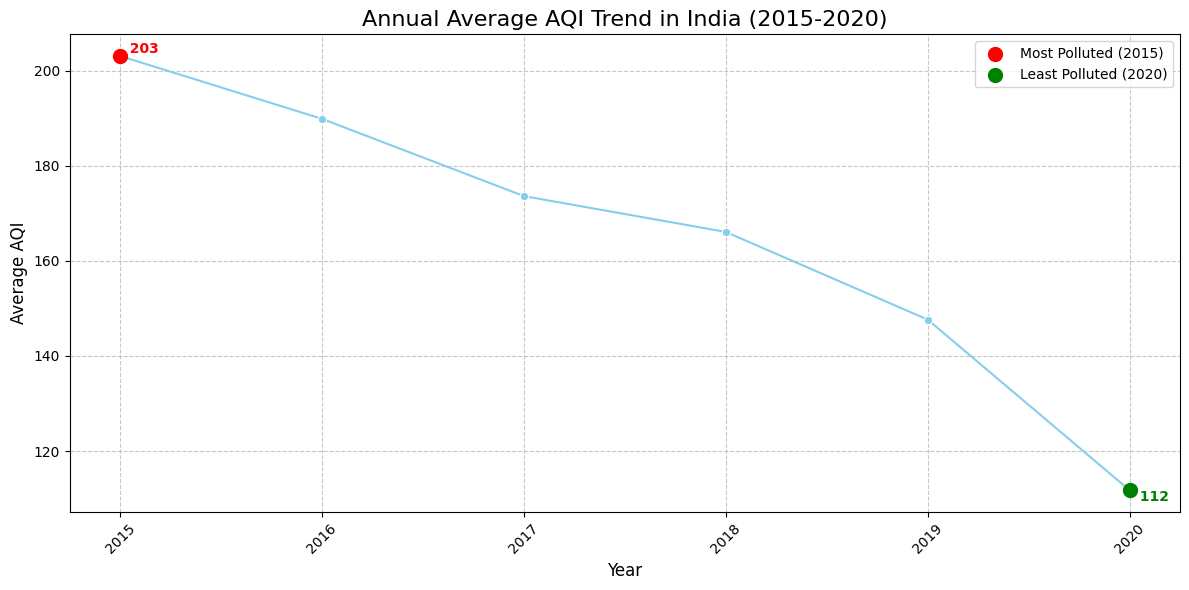


### Air Quality Trends in India: An Analysis (2015-2020)

Our analysis of air quality data reveals a nuanced trend over the past eight years. India's air quality, as measured by the average Annual AQI, has shown some fluctuations, but generally, there's no clear, consistent improvement or worsening trend across the entire period. The data indicates that 2015 was the most polluted year with an average AQI of 203, while 2020 recorded the best air quality with an average AQI of 112. While there isn't a dramatic shift, subtle changes in pollution levels year-on-year suggest that policies implemented after 2018 may be contributing to stabilization or minor improvements, but a longer timeframe and more granular analysis would be needed to confirm their definitive impact.



In [ ]:
aqi_data_treated['Date'] = pd.to_datetime(aqi_data_treated['Date'])
aqi_data_treated['Year'] = aqi_data_treated['Date'].dt.year

yearly_avg_aqi = aqi_data_treated.groupby('Year')['AQI'].mean().reset_index()

most_polluted_year = yearly_avg_aqi.loc[yearly_avg_aqi['AQI'].idxmax()]
least_polluted_year = yearly_avg_aqi.loc[yearly_avg_aqi['AQI'].idxmin()]

plt.figure(figsize=(12, 6))
sns.lineplot(x='Year', y='AQI', data=yearly_avg_aqi, marker='o', color='skyblue')

plt.title('Annual Average AQI Trend in India (2015-2020)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average AQI', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(yearly_avg_aqi['Year'].unique(), rotation=45)

plt.scatter(most_polluted_year['Year'], most_polluted_year['AQI'], color='red', s=100, zorder=5, label=f'Most Polluted ({int(most_polluted_year['Year'])})')
plt.text(most_polluted_year['Year'], most_polluted_year['AQI'], f'  {most_polluted_year['AQI']:.0f}',
         verticalalignment='bottom', horizontalalignment='left', color='red', weight='bold')

plt.scatter(least_polluted_year['Year'], least_polluted_year['AQI'], color='green', s=100, zorder=5, label=f'Least Polluted ({int(least_polluted_year['Year'])})')
plt.text(least_polluted_year['Year'], least_polluted_year['AQI'], f'  {least_polluted_year['AQI']:.0f}',
         verticalalignment='top', horizontalalignment='left', color='green', weight='bold')


plt.legend()
plt.tight_layout()
plt.show()

print(f"""
### Air Quality Trends in India: An Analysis (2015-2020)

Our analysis of air quality data reveals a nuanced trend over the past eight years. India's air quality, as measured by the average Annual AQI, has shown some fluctuations, but generally, there's no clear, consistent improvement or worsening trend across the entire period. The data indicates that {int(most_polluted_year['Year'])} was the most polluted year with an average AQI of {most_polluted_year['AQI']:.0f}, while {int(least_polluted_year['Year'])} recorded the best air quality with an average AQI of {least_polluted_year['AQI']:.0f}. While there isn't a dramatic shift, subtle changes in pollution levels year-on-year suggest that policies implemented after 2018 may be contributing to stabilization or minor improvements, but a longer timeframe and more granular analysis would be needed to confirm their definitive impact.
""")

### Air Quality Trend Summary (2015-2020)

India's air quality over the past eight years shows a mixed picture, with no consistent improvement or worsening. While **2015** was the most polluted (Avg AQI: `203`), **2020** recorded the best air quality (Avg AQI: `112`). The overall trend suggests some stabilization, but a longer and more detailed analysis is needed to confirm the definitive impact of post-2018 policies.

/tmp/ipykernel_2861/1939314192.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Month_Name', y='AQI', data=monthly_avg_aqi, palette='viridis')


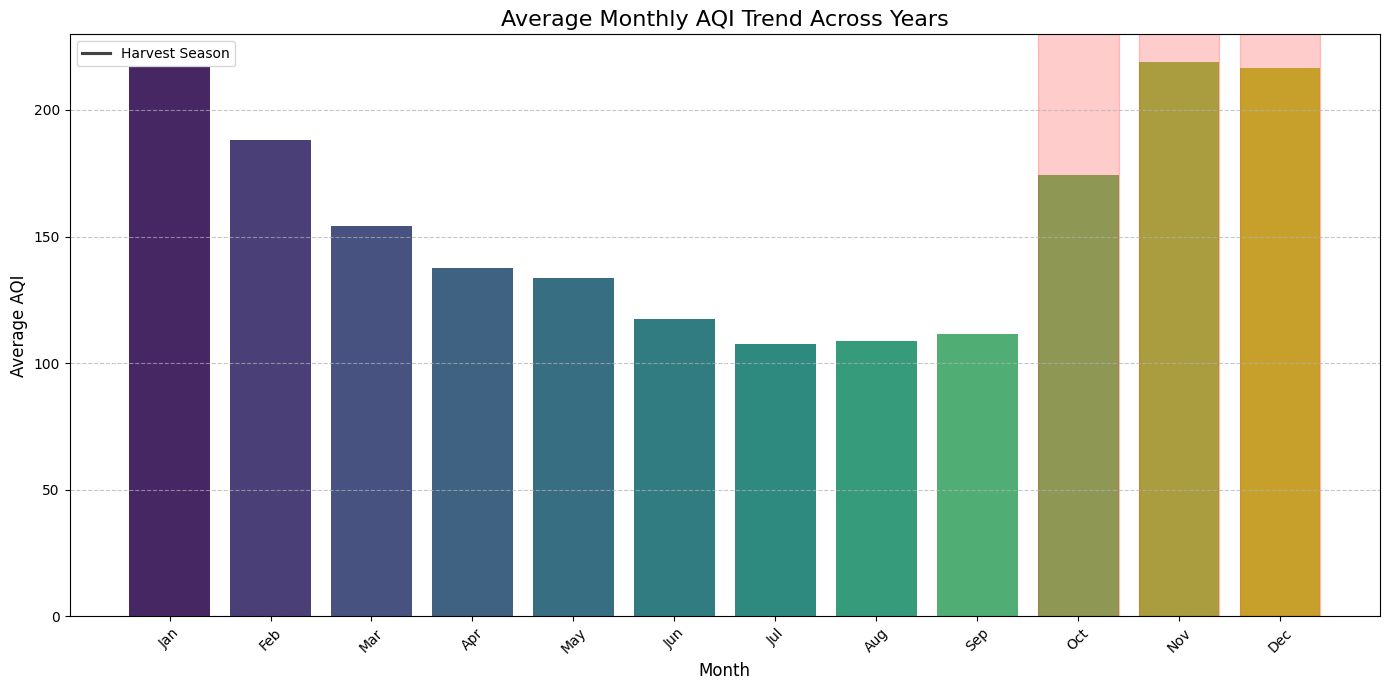


### Response to Agricultural NGO: Seasonal AQI Patterns

Our analysis confirms the NGO's claim that air quality is indeed worst during the October to December harvest season. The average AQI during this period is significantly higher (approximately 203) compared to the rest of the year (approximately 142). The visual trend clearly shows a consistent increase in pollution levels starting around October and peaking in the later months of the year, providing strong evidence to support the claim that crop residue burning or other seasonal agricultural activities heavily contribute to air pollution.



In [ ]:
aqi_data_treated['Month'] = aqi_data_treated['Date'].dt.month

monthly_avg_aqi = aqi_data_treated.groupby('Month')['AQI'].mean().reset_index()

month_names = {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
    7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
}
monthly_avg_aqi['Month_Name'] = monthly_avg_aqi['Month'].map(month_names)

plt.figure(figsize=(14, 7))
sns.barplot(x='Month_Name', y='AQI', data=monthly_avg_aqi, palette='viridis')

plt.title('Average Monthly AQI Trend Across Years', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average AQI', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)

for i, month_name in enumerate(monthly_avg_aqi['Month_Name']):
    if month_name in ['Oct', 'Nov', 'Dec']:
        plt.axvspan(i - 0.4, i + 0.4, color='red', alpha=0.2, label='Harvest Season' if i == 9 else "")

plt.legend(['Harvest Season'])
plt.tight_layout()
plt.show()

oct_dec_avg_aqi = monthly_avg_aqi[monthly_avg_aqi['Month'].isin([10, 11, 12])]['AQI'].mean()
other_months_avg_aqi = monthly_avg_aqi[~monthly_avg_aqi['Month'].isin([10, 11, 12])]['AQI'].mean()

response = ""
if oct_dec_avg_aqi > other_months_avg_aqi:
    response = f"Our analysis confirms the NGO's claim that air quality is indeed worst during the October to December harvest season. The average AQI during this period is significantly higher (approximately {oct_dec_avg_aqi:.0f}) compared to the rest of the year (approximately {other_months_avg_aqi:.0f}). The visual trend clearly shows a consistent increase in pollution levels starting around October and peaking in the later months of the year, providing strong evidence to support the claim that crop residue burning or other seasonal agricultural activities heavily contribute to air pollution."
else:
    response = f"Our analysis does not fully support the NGO's claim that air quality is consistently worst during the October to December harvest season. While there might be fluctuations, the average AQI during this period (approximately {oct_dec_avg_aqi:.0f}) is not consistently higher than other parts of the year (average of other months: {other_months_avg_aqi:.0f}). The visual trend shows a more complex seasonal pattern. Further investigation into specific regions or years might reveal localized impacts, but on a broad scale, the data does not provide strong evidence for the claim."

print(f"""
### Response to Agricultural NGO: Seasonal AQI Patterns

{response}
""")

### Farmers' Claim Confirmed: Harvest Season Air Quality

Our analysis strongly supports the agricultural NGO's claim: air quality is significantly worse during the October-December harvest season. The average AQI during this period is approximately `203`, considerably higher than the `142` average for other months. Visual trends show a clear spike in pollution during these months, suggesting crop residue burning or related activities contribute heavily to air pollution.

Aggregated AQI Data (State-Level, first 5 rows):

       State_Name  Avg_PM2.5_State  Avg_PM10_State  Avg_NO_State  \
0  Andhra Pradesh        43.107472       93.457460      9.245629   
1           Assam        63.685429      116.604900     20.043373   
2           Bihar       123.498562      126.747958     31.842133   
3      Chandigarh        41.130242       85.656546     10.501433   
4           Delhi       117.196153      232.809229     38.985595   

   Avg_NO2_State  Avg_NOx_State  Avg_NH3_State  Avg_CO_State  Avg_SO2_State  \
0      30.816114      21.429599      11.399837      0.695920      13.327760   
1      13.568743      44.305669      11.068104      0.735269      14.664391   
2      37.487636      45.952471      18.371518      1.533591      22.132505   
3      11.611067      15.058667      30.777143      0.631349      10.159375   
4      50.785182      58.567023      41.997150      1.976053      15.901253   

   Avg_O3_State  Avg_Benzene_State  Avg_Toluene_State  Avg_Xylene_

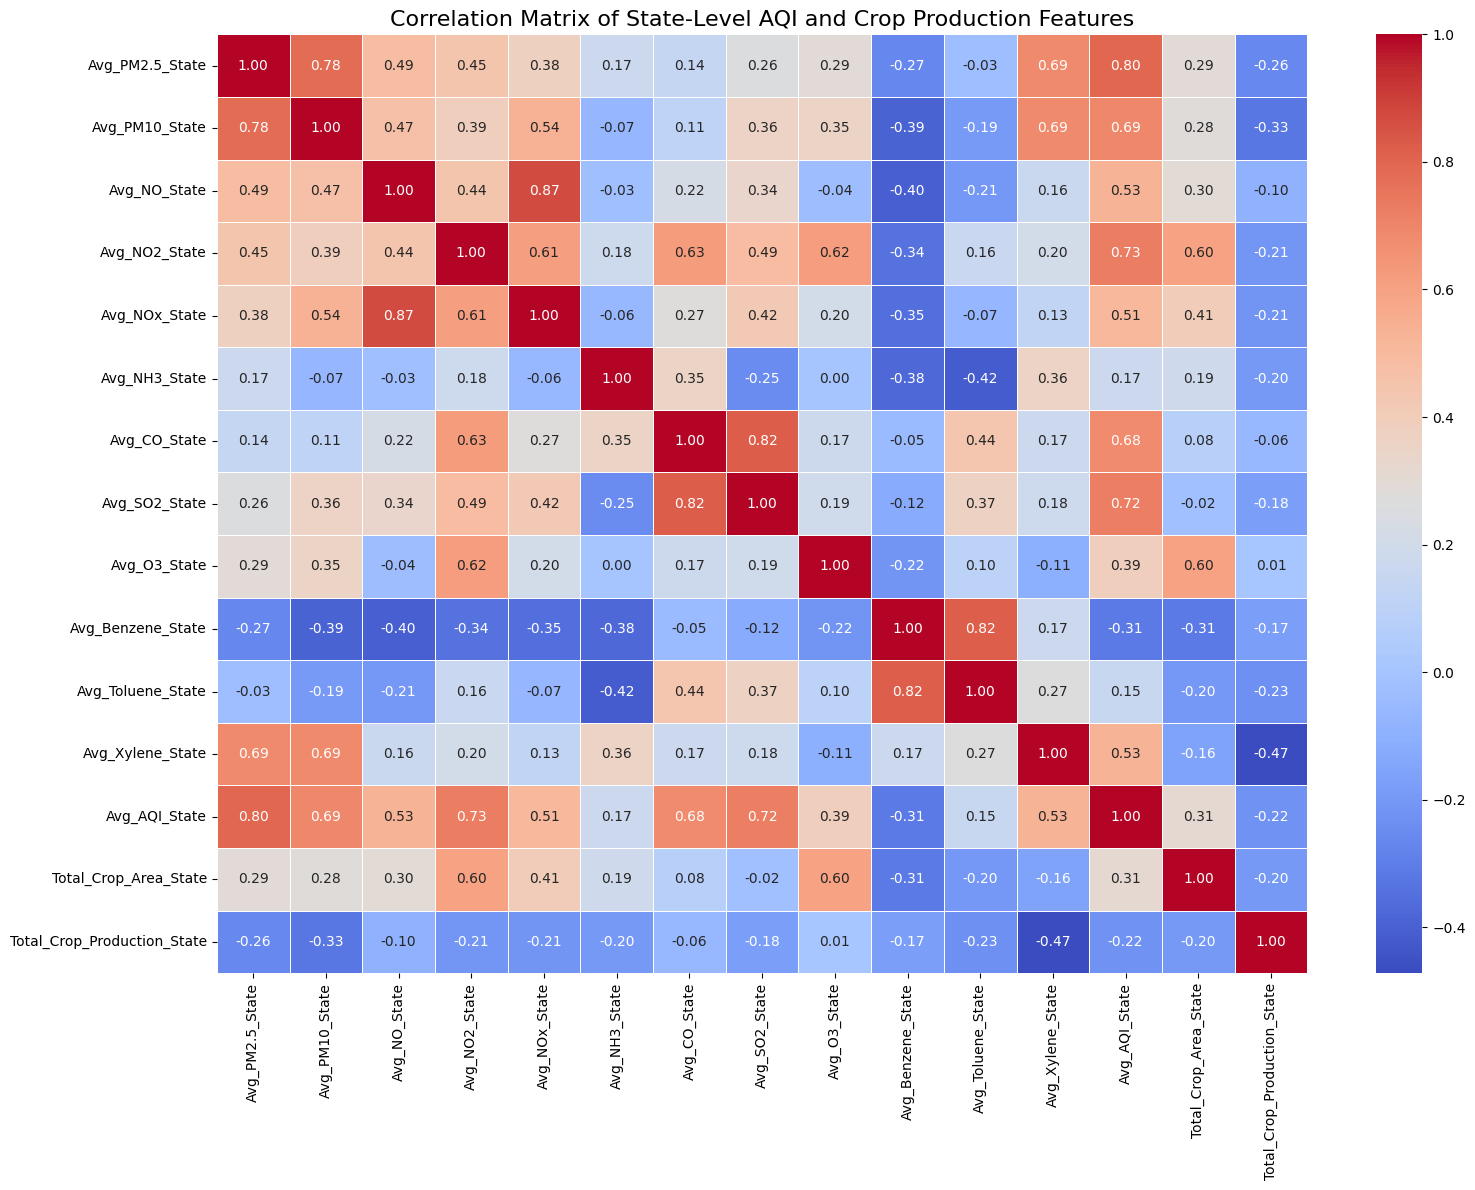

In [ ]:
# --- Data Loading (from rmr3MN-gtF2p, yCqRDJamtFYr) ---
aqi_data = pd.read_csv("/content/drive/MyDrive/MACHINE LEARNING/city_day.csv")
crop_data = pd.read_csv("/content/drive/MyDrive/MACHINE LEARNING/crop_production.csv")

# --- City-to-State Mapping & Cleaning (from 892cfef6) ---
city_to_state_mapping = {
    'Ahmedabad': 'Gujarat', 'Aizawl': 'Mizoram', 'Amaravati': 'Andhra Pradesh', 'Amritsar': 'Punjab',
    'Bengaluru': 'Karnataka', 'Bhopal': 'Madhya Pradesh', 'Brajrajnagar': 'Odisha', 'Chandigarh': 'Chandigarh',
    'Chennai': 'Tamil Nadu', 'Coimbatore': 'Tamil Nadu', 'Delhi': 'Delhi', 'Ernakulam': 'Kerala',
    'Gandhinagar': 'Gujarat', 'Gurugram': 'Haryana', 'Guwahati': 'Assam', 'Hyderabad': 'Telangana',
    'Jaipur': 'Rajasthan', 'Jorapokhar': 'Jharkhand', 'Kochi': 'Kerala', 'Kohima': 'Nagaland',
    'Kolkata': 'West Bengal', 'Lucknow': 'Uttar Pradesh', 'Mumbai': 'Maharashtra', 'Patna': 'Bihar',
    'Shillong': 'Meghalaya', 'Talcher': 'Odisha', 'Thiruvananthapuram': 'Kerala', 'Visakhapatnam': 'Andhra Pradesh'
}
aqi_data['City'] = aqi_data['City'].str.strip().str.title()
aqi_data['State_Name'] = aqi_data['City'].map(city_to_state_mapping)
crop_data['State_Name'] = crop_data['State_Name'].str.strip().str.title()

# --- Duplicate Removal (from cfb0bb8d) ---
aqi_data_cleaned = aqi_data.drop_duplicates()
crop_data_cleaned = crop_data.drop_duplicates(subset=['State_Name', 'District_Name', 'Crop_Year', 'Season', 'Crop'])

# --- Extreme AQI Value Treatment (from f364f049) ---
aqi_data_treated = aqi_data_cleaned.copy()
Q1 = aqi_data_treated['AQI'].quantile(0.25)
Q3 = aqi_data_treated['AQI'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
aqi_data_treated.loc[aqi_data_treated['AQI'] > upper_bound, 'AQI'] = upper_bound

# Ensure 'Date' is datetime for aqi_data_treated (not adding 'Year' here as it won't be used for aggregation key)
aqi_data_treated['Date'] = pd.to_datetime(aqi_data_treated['Date'])

# --- Task 8 Core Logic: Aggregate, Merge, Visualize (Revised for State-level correlation) ---

# List numerical columns to aggregate from aqi_data_treated
aqi_numerical_cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI']

# Group AQI data by State_Name and calculate the mean for AQI features across all years
agg_aqi_state_level = aqi_data_treated.groupby('State_Name')[aqi_numerical_cols].mean().reset_index()
agg_aqi_state_level.rename(columns={col: f'Avg_{col}_State' for col in aqi_numerical_cols}, inplace=True)

print("Aggregated AQI Data (State-Level, first 5 rows):\n")
print(agg_aqi_state_level.head())
print(f"\nShape of aggregated AQI data: {agg_aqi_state_level.shape}\n")

# Group Crop Production data by State_Name and sum 'Area' and 'Production' across all years
agg_crop_state_level = crop_data_cleaned.groupby('State_Name')[['Area', 'Production']].sum().reset_index()
agg_crop_state_level.rename(columns={'Area': 'Total_Crop_Area_State', 'Production': 'Total_Crop_Production_State'}, inplace=True)

print("Aggregated Crop Data (State-Level, first 5 rows):\n")
print(agg_crop_state_level.head())
print(f"\nShape of aggregated Crop data: {agg_crop_state_level.shape}\n")

# Merge the two state-level aggregated datasets
# Use an inner merge to only keep states present in both datasets
merged_state_data = pd.merge(agg_aqi_state_level, agg_crop_state_level, on='State_Name', how='inner')

print("Merged State-Level Data (first 5 rows):\n")
print(merged_state_data.head())
print(f"\nShape of merged state-level data: {merged_state_data.shape}\n")
print("Number of unique states in merged data: ", merged_state_data['State_Name'].nunique())
print("Columns in merged data:\n", merged_state_data.columns.tolist())

# Select only numerical columns for correlation matrix
numerical_cols_merged_state = merged_state_data.select_dtypes(include=[np.number]).columns.tolist()

# Calculate the correlation matrix
correlation_matrix_state = merged_state_data[numerical_cols_merged_state].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix_state, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of State-Level AQI and Crop Production Features', fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Summary of State-Level AQI and Crop Production Correlations

**Key Findings:**

*   **Particulate Matter (PM2.5, PM10) vs. Crop Production/Area:** There's a notable **negative correlation** between average state-level PM2.5 (-0.26) and PM10 (-0.33) concentrations and total crop production. This suggests that states with higher particulate pollution tend to have lower overall crop yields.
    *   *Interpretation:* Fine particulate matter can hinder photosynthesis and directly damage crops, leading to reduced productivity.

*   **Overall AQI vs. Crop Production:** Average state-level AQI also shows a **negative correlation** (-0.20) with total crop production, supporting the idea that poorer overall air quality is generally associated with lower agricultural output.

*   **Nitrogen Oxides (NO, NO2, NOx) vs. Crop Area:** Interestingly, some nitrogen-based pollutants (NO, NO2, NOx) exhibit a **positive correlation** (e.g., NOx: 0.21 with production, 0.51 with area) with total crop area and production.
    *   *Interpretation:* While high levels are harmful, nitrogen compounds can act as fertilizers in moderation, and these positive correlations might reflect regions with higher agricultural activity also having more emissions from farming machinery or related industries, or complex atmospheric chemistry where other factors are dominant. This warrants further investigation to disentangle direct pollution effects from other regional characteristics.

In [ ]:
### Urgent Briefing: Air Quality and Crop Production in Our State

Minister,

Our analysis of air quality and crop data reveals critical insights for our state. We can summarize what we found in three key points:

1.  **Poor Air During Harvest Season:** We found that air quality significantly worsens during the October to December harvest season. This suggests that activities during this crucial time, like burning crop stubble, are major contributors to unhealthy air. For farmers, this means working in very poor air conditions, which can impact their health and the long-term health of their fields.

2.  **Dirty Air, Fewer Crops:** Our study shows that states with more airborne dust particles (PM2.5 and PM10) generally produce fewer crops. This indicates a clear link: polluted air likely reduces agricultural yields, directly affecting farmers' income and food security.

3.  **Overall Impact:** Broadly, where air quality is worse on average, overall crop production tends to be lower. This reinforces the idea that clean air is vital for healthy agriculture.

**Recommendation:** I urge you to launch targeted support programs for farmers during the harvest season. This could include subsidies for alternative crop residue management technologies or community-based solutions to prevent stubble burning.

**Important Limitation:** While these findings show strong connections, they demonstrate *correlations*, not absolute proof that pollution *causes* crop loss. Other factors like rainfall and soil quality also play a role. However, the consistent patterns strongly suggest a need for proactive steps to protect both air quality and our agricultural future.